# Clustering Analysis: K-Means vs AgglomerativeClustering vs GMM

This notebook compares K-Means, AgglomerativeClustering, and Gaussian Mixture Model (GMM) clustering methods on the transposed variant mean data.
We evaluate clustering quality using:
- Silhouette Coefficient (higher is better)


For k = 3, 5, 7, 9 clusters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from pathlib import Path
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from sklearn.manifold import TSNE


In [3]:
from mylib import genomes

In [4]:
root_dir = join(Path.home(),"projects/cp_als/second_pair/populations/output/CD")

## Data Preparation
Load and prepare the same data as in the original notebook (cell 5-7)

In [5]:
# Cell 5: Create aggregated dataframe
adf = pd.DataFrame(columns=genomes.keys())
for population_name in genomes:
    genome_ids = genomes[population_name]
    df = pd.read_csv(join(root_dir,f"{population_name}/all.csv"))
    df = df[genomes[population_name]+["gene"]]
    variant_mean = df.groupby(['gene']).sum().mean(axis=1)
    #variant_mean = df.groupby(['gene']).mean().mean(axis=1)
    adf[population_name] = variant_mean

# Remove disease-associated genes before clustering
adf = adf.drop(index=["NOD2", "IL23R", "ATG16L1", "STAT3"], errors="ignore")

In [6]:
# Cell 6: Display the aggregated dataframe
adf.head(10)

,ACB,ASW,BEB,CDX,CHB,CHS,CLM,ESN,FIN,GBR,...,KHV,LWK,MSL,MXL,PEL,PJL,PUR,STU,TSI,YRI
gene,,,,,,,,,,,,,,,,,,,,,
ABCB1,171.154639,161.518519,113.383721,121.924731,122.627451,129.733333,133.212766,180.01,114.019417,117.052083,...,126.333333,181.744898,174.744444,125.428571,135.588235,120.291667,131.182692,111.009804,119.685185,171.068627
ATG4C,110.309278,114.462963,92.395349,89.419355,88.500000,85.876190,97.670213,119.02,83.349515,76.187500,...,91.303030,116.408163,121.055556,95.587302,104.870588,81.885417,105.519231,87.901961,94.453704,119.745098
CARD9,7.567010,7.500000,7.174419,8.505376,6.254902,6.447619,9.351064,7.65,6.970874,7.302083,...,7.343434,7.663265,7.211111,8.761905,10.729412,7.145833,8.375000,7.117647,7.324074,7.274510
CDKAL1,1099.680412,1087.000000,910.476744,901.806452,917.147059,899.695238,934.095745,1107.30,922.514563,904.208333,...,919.959596,1098.744898,1141.855556,919.047619,912.000000,896.177083,944.817308,880.960784,897.870370,1113.607843
DLG5,199.701031,195.944444,189.604651,181.602151,189.392157,184.857143,200.797872,197.05,183.543689,185.333333,...,188.626263,188.346939,200.777778,210.253968,210.494118,190.270833,199.884615,182.529412,157.601852,201.931373
GPR35,46.278351,47.759259,56.290698,58.666667,57.803922,57.657143,50.521277,46.25,51.320388,51.281250,...,59.252525,45.653061,46.311111,49.063492,50.176471,52.677083,49.288462,55.774510,48.787037,46.127451
HLA-DRB1,3.752577,4.259259,3.500000,3.688172,3.656863,3.142857,7.000000,2.44,8.475728,5.375000,...,3.484848,2.959184,3.977778,4.650794,5.047059,1.510417,5.586538,2.460784,4.537037,2.235294
IL10,7.546392,7.407407,6.639535,4.956989,3.941176,4.533333,8.446809,7.31,9.116505,9.739583,...,4.707071,7.540816,6.255556,8.158730,7.235294,7.781250,7.750000,6.196078,8.824074,6.901961
IL10RA,21.876289,21.462963,21.000000,24.182796,22.705882,23.133333,16.138298,23.44,15.990291,16.968750,...,23.818182,20.346939,22.777778,20.063492,21.647059,18.604167,20.067308,18.245098,17.712963,23.352941


In [7]:
# Cell 7: Transpose the dataframe (populations as rows, genes as columns)
tdf = adf.transpose()

# Apply StandardScaler to normalize the features
scaler = StandardScaler()
tdf_scaled = pd.DataFrame(
    scaler.fit_transform(tdf),
    index=tdf.index,
    columns=tdf.columns
)

# Use the scaled data for clustering
tdf = tdf_scaled

print(f"Data shape: {tdf.shape}")
print(f"Populations (samples): {tdf.shape[0]}")
print(f"Genes (features): {tdf.shape[1]}")
print(f"Data has been standardized (mean=0, std=1)")
tdf.head()

Data shape: (25, 25)
Populations (samples): 25
Genes (features): 25
Data has been standardized (mean=0, std=1)


gene,ABCB1,ATG4C,CARD9,CDKAL1,DLG5,GPR35,HLA-DRB1,IL10,IL10RA,IL10RB,...,MST1,NKX2-3,PTPN2,PTPN22,SLC22A4,SLC22A5,TLR4,TNF,TNFSF15,ZMIZ1
ACB,1.440302,0.954071,0.013477,1.439898,0.773800,-1.166401,-0.124460,0.348335,0.442922,0.833715,...,1.071785,0.293115,1.622289,0.590299,0.777427,-0.554120,1.230098,-1.105584,1.035634,0.921133
ASW,1.039569,1.261404,-0.056776,1.304236,0.478363,-0.845081,0.184609,0.256685,0.292783,0.981063,...,1.068125,-0.315673,1.509344,0.531306,0.796215,-0.890446,0.986103,1.132870,0.240007,1.272463
BEB,-0.962192,-0.371388,-0.398113,-0.584316,-0.020231,1.006025,-0.278528,-0.249671,0.124613,0.522719,...,-0.511987,1.292533,-1.268290,0.412536,-1.648797,0.555985,-0.117689,0.883949,-0.380888,-0.231517
CDX,-0.607001,-0.591583,0.997254,-0.677076,-0.649589,1.521550,-0.163746,-1.359187,1.280753,-1.754847,...,-1.402804,-1.069021,-0.982536,-2.024552,1.459002,1.631647,-0.847221,-1.461641,-1.232230,0.186094
CHB,-0.577777,-0.659607,-1.362128,-0.512953,-0.036943,1.334356,-0.182844,-2.029041,0.744269,-0.863040,...,-1.259182,-0.799787,-0.404110,-2.019220,0.678709,0.789034,-1.086687,-1.084303,-1.446436,0.487600


## Clustering Analysis

We'll apply both K-Means and Hierarchical clustering for k=3, 5, 7 clusters and evaluate each using three metrics.

In [8]:
def evaluate_clustering(data, labels, method_name, k):
    """
    Evaluate clustering quality using three metrics.
    
    Parameters:
    - data: feature matrix
    - labels: cluster labels
    - method_name: name of clustering method
    - k: number of clusters
    
    Returns:
    - Dictionary with evaluation metrics
    """
    silhouette = silhouette_score(data, labels)
    davies_bouldin = davies_bouldin_score(data, labels)
    
    return {
        'Method': method_name,
        'K': k,
        'Silhouette Coefficient': silhouette,
        'Davies-Bouldin Index': davies_bouldin
    }

In [9]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Metric evaluation (robust)
# -----------------------------
def compute_metrics(X, labels):
    """
    Returns silhouette and davies-bouldin.
    Handles degenerate cases (e.g., 1 cluster in a bootstrap sample).
    """
    unique = np.unique(labels)
    if len(unique) < 2 or X.shape[0] < 3:
        # silhouette and DB are undefined / unstable with <2 clusters or too few points
        return np.nan, np.nan

    sil = silhouette_score(X, labels)
    db = davies_bouldin_score(X, labels)
    return sil, db


# -----------------------------
# Bootstrap runner
# -----------------------------
def bootstrap_clustering_metrics(
    X,
    k_values=(3, 5, 7),
    n_boot=10,
    base_seed=42,
    scale=False,
    kmeans_n_init=10,
    gmm_n_init=10,
):
    """
    Bootstraps rows of X (sampling with replacement) to estimate variability
    for KMeans, AgglomerativeClustering, and GMM fairly.

    Returns:
      runs_df: per-run results
      summary_df: mean/std/95% CI for plotting
    """
    X = np.asarray(X)

    # optional scaling (often good if feature scales differ)
    if scale:
        X = StandardScaler().fit_transform(X)

    n = X.shape[0]
    rng = np.random.default_rng(base_seed)

    methods = ["K-Means", "AgglomerativeClustering", "Gaussian Mixture Models"]
    runs = []

    for k in k_values:
        print(f"\n=== k = {k} ===")

        for run in range(n_boot):
            # Bootstrap sample indices (same for ALL methods => fair)
            # Seeded by base rng so it's reproducible.
            idx = rng.integers(0, n, size=n)
            Xb = X[idx]

            # Also give each run a deterministic seed for stochastic methods
            run_seed = base_seed + run

            # ---- K-Means
            km = KMeans(n_clusters=k, random_state=run_seed, n_init=kmeans_n_init)
            km_labels = km.fit_predict(Xb)
            km_sil, km_db = compute_metrics(Xb, km_labels)
            runs.append({
                "Method": "K-Means",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": km_sil,
                "Davies-Bouldin Index": km_db,
            })

            # ---- Agglomerative (deterministic on Xb, but Xb varies => CI meaningful)
            agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
            agg_labels = agg.fit_predict(Xb)
            agg_sil, agg_db = compute_metrics(Xb, agg_labels)
            runs.append({
                "Method": "AgglomerativeClustering",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": agg_sil,
                "Davies-Bouldin Index": agg_db,
            })

            # ---- GMM
            gmm = GaussianMixture(n_components=k, random_state=run_seed, n_init=gmm_n_init)
            gmm_labels = gmm.fit_predict(Xb)
            gmm_sil, gmm_db = compute_metrics(Xb, gmm_labels)
            runs.append({
                "Method": "Gaussian Mixture Models",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": gmm_sil,
                "Davies-Bouldin Index": gmm_db,
            })

        print(f"Completed {n_boot} bootstrap runs for k={k} across all methods.")

    runs_df = pd.DataFrame(runs)

    # Summaries for plotting mean ± 95% CI (ignore NaNs safely)
    def summarize(g):
        n_eff_s = g["Silhouette Coefficient"].notna().sum()
        mean_s  = g["Silhouette Coefficient"].mean()
        std_s   = g["Silhouette Coefficient"].std(ddof=1) if n_eff_s > 1 else 0.0
        ci_s    = 1.96 * std_s / np.sqrt(n_eff_s) if n_eff_s > 1 else 0.0

        n_eff_d = g["Davies-Bouldin Index"].notna().sum()
        mean_d  = g["Davies-Bouldin Index"].mean()
        std_d   = g["Davies-Bouldin Index"].std(ddof=1) if n_eff_d > 1 else 0.0
        ci_d    = 1.96 * std_d / np.sqrt(n_eff_d) if n_eff_d > 1 else 0.0

        return pd.Series({
            "n_runs_total": len(g),
            "n_eff_silhouette": n_eff_s,
            "Silhouette Mean": mean_s,
            "Silhouette Std": std_s,
            "Silhouette 95CI": ci_s,
            "n_eff_davies": n_eff_d,
            "Davies Mean": mean_d,
            "Davies Std": std_d,
            "Davies 95CI": ci_d,
        })

    summary_df = runs_df.groupby(["Method", "K"], as_index=False).apply(summarize)

    return runs_df, summary_df

In [10]:
X = tdf.values

runs_df, summary_df = bootstrap_clustering_metrics(
    X,
    #k_values=[3, 4, 5, 6,7 , 8],
    k_values=[3, 5, 7],
    n_boot=10,
    base_seed=42,
    scale=True  # set True if feature scales differ a lot
)

print(runs_df.head())
print(summary_df)


=== k = 3 ===
Completed 10 bootstrap runs for k=3 across all methods.

=== k = 5 ===
Completed 10 bootstrap runs for k=5 across all methods.

=== k = 7 ===
Completed 10 bootstrap runs for k=7 across all methods.
                    Method  K  Run  Seed  Silhouette Coefficient  \
0                  K-Means  3    0    42                0.482759   
1  AgglomerativeClustering  3    0    42                0.509006   
2  Gaussian Mixture Models  3    0    42                0.482759   
3                  K-Means  3    1    43                0.487711   
4  AgglomerativeClustering  3    1    43                0.487711   

   Davies-Bouldin Index  
0              0.752167  
1              0.634196  
2              0.752167  
3              0.776243  
4              0.776243  
                    Method  K  n_runs_total  n_eff_silhouette  \
0  AgglomerativeClustering  3          10.0              10.0   
1  AgglomerativeClustering  5          10.0              10.0   
2  AgglomerativeClustering 

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_silhouette_for_pdf(
    summary_df,
    k_values=(3, 5, 7),
    highlight_k=None,
    out_dir="plots",
    filename="silhouette_k_selection.pdf",
    #figsize=(2.6, 2.4),   # match TSNE and PCA subfigure sizing
    figsize=(6, 4),
):
    os.makedirs(out_dir, exist_ok=True)

    # PDF-friendly font embedding
    plt.rcParams["pdf.fonttype"] = 42
    plt.rcParams["ps.fonttype"] = 42

    colors = {
        "K-Means": "#1F4E79",
        "AgglomerativeClustering": "#C00000",
        "Gaussian Mixture Models": "#2E7D32"
    }

    methods = ["K-Means", "AgglomerativeClustering", "Gaussian Mixture Models"]
    x = np.arange(len(k_values))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    if highlight_k is not None and highlight_k in k_values:
        hk_idx = k_values.index(highlight_k)
        ax.axvspan(hk_idx - 0.5, hk_idx + 0.5, alpha=0.10, zorder=0)

    offsets = {
        "K-Means": -0.18,
        "AgglomerativeClustering": 0.00,
        "Gaussian Mixture Models": 0.18
    }

    for method in methods:
        mdf = summary_df[
            (summary_df["Method"] == method) &
            (summary_df["K"].isin(k_values))
        ].copy()

        mdf = mdf.set_index("K").loc[list(k_values)].reset_index()

        y = mdf["Silhouette Mean"].values
        yerr = mdf["Silhouette 95CI"].values
        x_method = x + offsets[method]

        ax.errorbar(
            x_method,
            y,
            yerr=yerr,
            fmt="o",
            markersize=4.0,
            capsize=2.2,
            capthick=0.8,
            elinewidth=0.9,
            color=colors[method],
            alpha=0.95,
            label=method,
            markeredgecolor="black",
            markeredgewidth=0.35,
            zorder=3
        )

    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=6)

    ax.set_xlabel("Number of Clusters ($k$)", fontsize=7)
    ax.set_ylabel("Silhouette Coefficient", fontsize=7)

    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="y", labelsize=6)

    ax.legend(
        frameon=True,
        fontsize=5.2,
        loc="best",
        handlelength=1.0,
        borderpad=0.25,
        labelspacing=0.25,
        handletextpad=0.4
    )

    plt.tight_layout()

    # out_path = os.path.join(out_dir, filename)

    # plt.savefig(
    #     out_path,
    #     format="pdf",
    #     bbox_inches="tight",
    #     facecolor="white"
    # )
    plt.show()
    #plt.close()

    # print(f"Saved: {out_path}")
    # return out_path

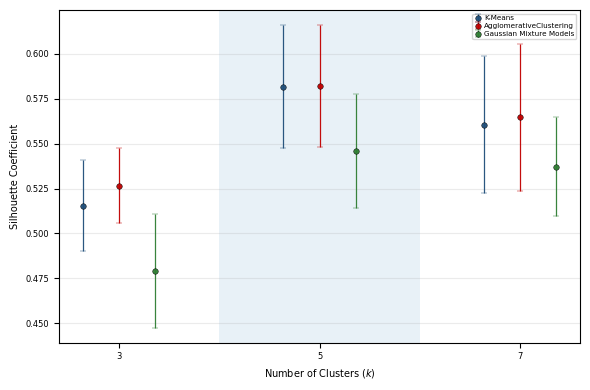

In [20]:
plot_silhouette_for_pdf(
    summary_df,
    k_values=[3, 5, 7],
    highlight_k=5,
    filename="silhouette_k_selection_cd.pdf"
)